# Phase 6: Churn Baseline Modeling (Leakage-Safe Track)

This notebook now follows a leakage-safe baseline strategy with explicit decisions and audit artifacts.

## Decision Flow Implemented In This Notebook

1. Define a plausible proxy churn label from the mart (`churn_flag_90d`).
2. Apply **Option 1 (rule blacklist)** to remove obvious leakage and proxy-label mirrors.
3. Apply **Option 2 (automated screening)** on training data to flag suspiciously predictive single features.
4. Train baseline models only on approved features.
5. Export both model results and leakage-audit artifacts for traceability.

## Options Status

- **Implemented now**: Option 1 + Option 2.
- **Mentioned for next iterations**:

### Option 3: Snapshot + Horizon Supervision
Build features at time T, define churn on T+1..T+90 behavior, and evaluate on later time windows only.

### Option 4: Proxy Family Exclusion
Keep proxy label but drop the entire recency/time-since-last-action family, not just one column.

### Option 5: Dual Reporting
Publish two baselines (all-features vs leakage-safe) and treat the difference as leakage sensitivity evidence.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
    log_loss,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    )

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA = ROOT / 'data' / 'processed'
OUT = ROOT / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.05), 2)
AUTO_LEAK_AUC_THRESHOLD = 0.95

print(f'Root: {ROOT}')
print(f'Data exists: {DATA.exists()} | Out: {OUT}')

Root: C:\Users\USER\Documents\Python Projects\retail-intelligence
Data exists: True | Out: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [12]:
df = pd.read_csv(DATA / 'mart_customer_features.csv')

for dcol in ['signup_date', 'first_order_date', 'last_order_date']:
    if dcol in df.columns:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

target = 'churn_flag_90d'
if target not in df.columns:
    raise ValueError(f'Missing target column: {target}')

df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

# Option 1: rule-based leakage blacklist (explicit and auditable).
rule_blacklist_exact = {
    'customer_id',
    'signup_date',
    'first_order_date',
    'last_order_date',
    target,
    'is_churned',
    'churn_probability',
    'future_orders_90d',
    'future_revenue_90d',
    'recency_days',
}
rule_blacklist_contains = [
    'churn',
    'recency',
    'last_order',
    'future_',
]

candidate_cols = [c for c in df.columns if c != target]
X_all = df[candidate_cols].copy()
y_all = df[target].copy()

# Split first, then run automated screening only on train (to avoid peeking).
time_split_used = False
if 'last_order_date' in df.columns and df['last_order_date'].notna().sum() > int(0.8 * len(df)):
    split_ix = int(len(df) * 0.8)
    order = df.sort_values('last_order_date').index
    train_idx = order[:split_ix]
    test_idx = order[split_ix:]
    X_train_t, X_test_t = X_all.loc[train_idx], X_all.loc[test_idx]
    y_train_t, y_test_t = y_all.loc[train_idx], y_all.loc[test_idx]

    if y_train_t.nunique() == 2 and y_test_t.nunique() == 2:
        X_train_raw, X_test_raw = X_train_t, X_test_t
        y_train, y_test = y_train_t, y_test_t
        split_strategy = 'time_ordered_80_20_by_last_order_date'
        time_split_used = True

if not time_split_used:
    from sklearn.model_selection import train_test_split
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
    )
    split_strategy = 'stratified_random_80_20'

# Option 2: automated suspicious-feature screening via univariate train-only AUC.
def single_feature_auc(x: pd.Series, y: pd.Series) -> float:
    if y.nunique() < 2:
        return np.nan

    if is_numeric_dtype(x):
        s = x.astype(float).fillna(x.astype(float).median())
    else:
        cat = x.astype('string').fillna('__MISSING__')
        target_rate = pd.DataFrame({'cat': cat, 'y': y}).groupby('cat', dropna=False)['y'].mean()
        s = cat.map(target_rate).astype(float).fillna(y.mean())

    if s.nunique() <= 1:
        return np.nan
    auc_val = roc_auc_score(y, s)
    return float(max(auc_val, 1.0 - auc_val))

leakage_rows = []
approved_features = []

for col in X_train_raw.columns:
    reasons = []
    lower_col = col.lower()

    if col in rule_blacklist_exact:
        reasons.append('rule_blacklist_exact')

    for key in rule_blacklist_contains:
        if key in lower_col:
            reasons.append(f'rule_blacklist_contains:{key}')
            break

    auc_val = single_feature_auc(X_train_raw[col], y_train)
    auto_flag = pd.notna(auc_val) and auc_val >= AUTO_LEAK_AUC_THRESHOLD
    if auto_flag:
        reasons.append(f'auto_leak_auc>={AUTO_LEAK_AUC_THRESHOLD:.2f}')

    action = 'drop' if len(reasons) > 0 else 'keep'
    if action == 'keep':
        approved_features.append(col)

    leakage_rows.append({
        'feature': col,
        'single_feature_auc_train': auc_val,
        'auto_leak_threshold': AUTO_LEAK_AUC_THRESHOLD,
        'auto_flag': bool(auto_flag),
        'action': action,
        'reasons': ';'.join(reasons) if reasons else 'none',
    })

leakage_audit = pd.DataFrame(leakage_rows).sort_values(['action', 'single_feature_auc_train'], ascending=[True, False])

X_train = X_train_raw[approved_features].copy()
X_test = X_test_raw[approved_features].copy()

leakage_path = OUT / 'phase6_churn_leakage_audit.csv'
approved_path = OUT / 'phase6_churn_approved_features.csv'
leakage_audit.to_csv(leakage_path, index=False)
pd.DataFrame({'feature': approved_features}).to_csv(approved_path, index=False)

base_rate = y_all.mean()
print(f'Split strategy: {split_strategy}')
print(f'Churn base rate: {base_rate:.4f} ({y_all.sum()} / {len(y_all)})')
print(f'Train class counts: {y_train.value_counts().to_dict()}')
print(f'Test class counts: {y_test.value_counts().to_dict()}')
print(f'Raw features: {X_train_raw.shape[1]} | Approved features: {X_train.shape[1]}')
print(f'Leakage audit path: {leakage_path}')
print(f'Approved feature list: {approved_path}')
display(leakage_audit.head(20))

Split strategy: stratified_random_80_20
Churn base rate: 0.1712 (8561 / 50000)
Train class counts: {0: 33151, 1: 6849}
Test class counts: {0: 8288, 1: 1712}
Raw features: 39 | Approved features: 34
Leakage audit path: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_leakage_audit.csv
Approved feature list: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_approved_features.csv


,feature,single_feature_auc_train,auto_leak_threshold,auto_flag,action,reasons
0,customer_id,1.000000,0.95,True,drop,rule_blacklist_exact;auto_leak_auc>=0.95
15,last_order_date,1.000000,0.95,True,drop,rule_blacklist_exact;rule_blacklist_contains:l...
16,recency_days,1.000000,0.95,True,drop,rule_blacklist_exact;rule_blacklist_contains:r...
14,first_order_date,0.714027,0.95,False,drop,rule_blacklist_exact
8,signup_date,0.672325,0.95,False,drop,rule_blacklist_exact
21,total_units,0.759882,0.95,False,keep,none
9,total_orders,0.759383,0.95,False,keep,none
37,customer_value_band,0.753614,0.95,False,keep,none
10,total_net_revenue,0.751065,0.95,False,keep,none
12,total_discount_amount,0.749789,0.95,False,keep,none


In [13]:
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_cols,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ]),
            cat_cols,
        ),
    ]
)

models = {
    'logreg_balanced': LogisticRegression(
        max_iter=1200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    'rf_balanced': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=3,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

print(f'Numeric features: {len(num_cols)} | Categorical features: {len(cat_cols)}')

Numeric features: 27 | Categorical features: 7


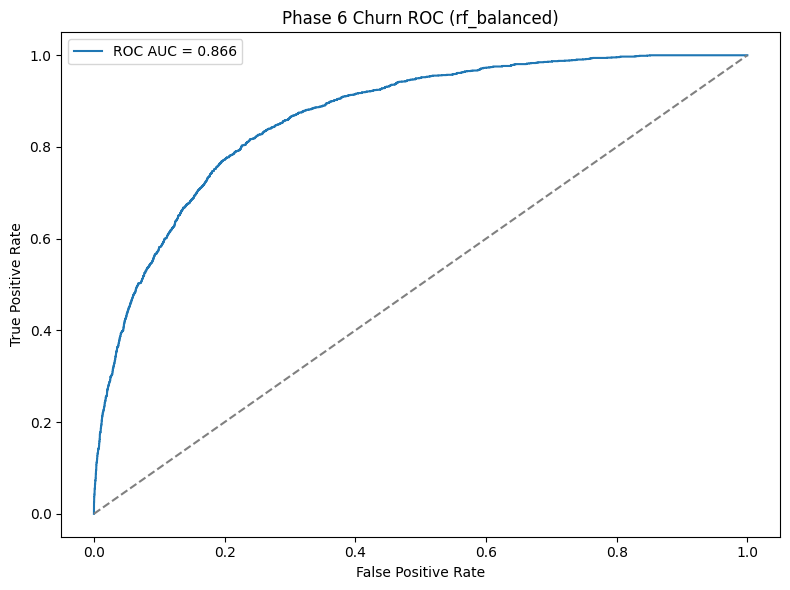

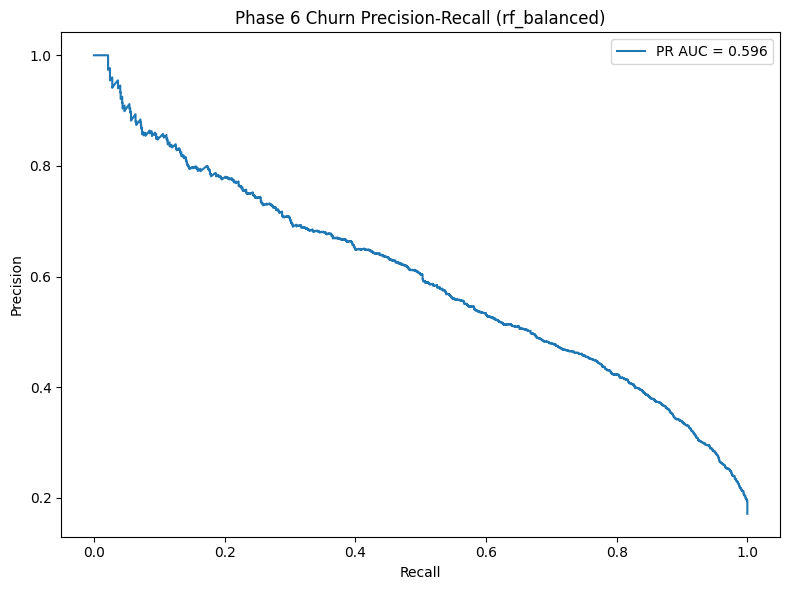

Model comparison:


,model,split_strategy,approved_feature_count,train_rows,test_rows,churn_rate_train,churn_rate_test,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0_50,balanced_accuracy_at_0_50,mcc_at_0_50
1,rf_balanced,stratified_random_80_20,34,40000,10000,0.171225,0.1712,0.865636,0.596499,0.329855,0.102605,0.8552,0.717066,0.461553
0,logreg_balanced,stratified_random_80_20,34,40000,10000,0.171225,0.1712,0.847734,0.555328,0.482645,0.160991,0.7637,0.768461,0.429893



Chosen thresholds:


,selection_rule,model,threshold,precision,recall,f1,specificity
0,max_f1,rf_balanced,0.35,0.495704,0.674065,0.571287,0.858349
1,precision_floor_0_70,rf_balanced,0.70,0.745583,0.246495,0.370500,0.982625



Top features:


,feature,importance
0,num__tenure_days,0.123368
1,num__total_units,0.070150
2,num__total_orders,0.061048
3,num__total_discount_amount,0.060763
4,num__total_net_revenue,0.059835
5,num__spend_rank_in_region,0.041326
6,num__avg_item_discount_pct,0.035443
7,num__revenue_per_order,0.029104
8,num__total_returns,0.029028
9,num__avg_item_margin,0.028781



Classification report at max_f1 threshold:
              precision    recall  f1-score   support

           0     0.9273    0.8583    0.8915      8288
           1     0.4957    0.6741    0.5713      1712

    accuracy                         0.8268     10000
   macro avg     0.7115    0.7662    0.7314     10000
weighted avg     0.8534    0.8268    0.8367     10000

Artifacts written:
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_leakage_audit.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_approved_features.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_model_comparison.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_threshold_diagnostics.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_threshold_selection.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase6_churn_feature_impor

In [14]:
model_rows = []
threshold_rows = []
best_bundle = None

for model_name, model in models.items():
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred_50 = (proba >= 0.5).astype(int)

    model_row = {
        'model': model_name,
        'split_strategy': split_strategy,
        'approved_feature_count': X_train.shape[1],
        'train_rows': len(X_train),
        'test_rows': len(X_test),
        'churn_rate_train': y_train.mean(),
        'churn_rate_test': y_test.mean(),
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'log_loss': log_loss(y_test, proba),
        'brier_score': brier_score_loss(y_test, proba),
        'accuracy_at_0_50': accuracy_score(y_test, pred_50),
        'balanced_accuracy_at_0_50': balanced_accuracy_score(y_test, pred_50),
        'mcc_at_0_50': matthews_corrcoef(y_test, pred_50),
    }
    model_rows.append(model_row)

    for thr in THRESHOLDS:
        pred = (proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
        threshold_rows.append({
            'model': model_name,
            'threshold': float(thr),
            'precision': precision_score(y_test, pred, zero_division=0),
            'recall': recall_score(y_test, pred, zero_division=0),
            'f1': f1_score(y_test, pred, zero_division=0),
            'specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
            'tp': int(tp),
            'fp': int(fp),
            'tn': int(tn),
            'fn': int(fn),
            'positive_rate': pred.mean(),
        })

    if best_bundle is None or model_row['pr_auc'] > best_bundle['pr_auc']:
        best_bundle = {'model': model_name, 'pipe': pipe, 'proba': proba, 'pr_auc': model_row['pr_auc']}

comparison = pd.DataFrame(model_rows).sort_values(['pr_auc', 'roc_auc'], ascending=False)
threshold_diag = pd.DataFrame(threshold_rows).sort_values(['model', 'threshold']).reset_index(drop=True)

best_model_name = comparison.iloc[0]['model']
best_thr_table = threshold_diag[threshold_diag['model'] == best_model_name].copy()
best_row_f1 = best_thr_table.sort_values(['f1', 'recall'], ascending=False).iloc[0]
precision_floor = 0.70
eligible = best_thr_table[best_thr_table['precision'] >= precision_floor]
if len(eligible) > 0:
    best_row_precision = eligible.sort_values(['recall', 'f1'], ascending=False).iloc[0]
else:
    best_row_precision = best_row_f1

selected = pd.DataFrame([
    {
        'selection_rule': 'max_f1',
        'model': best_model_name,
        'threshold': float(best_row_f1['threshold']),
        'precision': float(best_row_f1['precision']),
        'recall': float(best_row_f1['recall']),
        'f1': float(best_row_f1['f1']),
        'specificity': float(best_row_f1['specificity']),
    },
    {
        'selection_rule': 'precision_floor_0_70',
        'model': best_model_name,
        'threshold': float(best_row_precision['threshold']),
        'precision': float(best_row_precision['precision']),
        'recall': float(best_row_precision['recall']),
        'f1': float(best_row_precision['f1']),
        'specificity': float(best_row_precision['specificity']),
    },
])

best_pipe = best_bundle['pipe']
best_estimator = best_pipe.named_steps['model']
feature_names = best_pipe.named_steps['pre'].get_feature_names_out()

if hasattr(best_estimator, 'feature_importances_'):
    imp_vals = best_estimator.feature_importances_
else:
    imp_vals = np.abs(best_estimator.coef_).ravel()

fi = (
    pd.DataFrame({'feature': feature_names, 'importance': imp_vals})
    .sort_values('importance', ascending=False)
    .head(30)
    .reset_index(drop=True)
)

scored = X_test.copy()
scored['actual_churn'] = y_test.values
scored['score_churn_proba'] = best_bundle['proba']
scored = scored.sort_values('score_churn_proba', ascending=False).reset_index(drop=True)
scored['rank'] = np.arange(1, len(scored) + 1)

fpr, tpr, _ = roc_curve(y_test, best_bundle['proba'])
roc_auc_val = auc(fpr, tpr)
pr_prec, pr_rec, _ = precision_recall_curve(y_test, best_bundle['proba'])
pr_auc_val = auc(pr_rec, pr_prec)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_val:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Phase 6 Churn ROC ({best_model_name})')
plt.legend()
plt.tight_layout()
roc_path = OUT / 'phase6_churn_roc_curve.png'
plt.savefig(roc_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(pr_rec, pr_prec, label=f'PR AUC = {pr_auc_val:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Phase 6 Churn Precision-Recall ({best_model_name})')
plt.legend()
plt.tight_layout()
pr_path = OUT / 'phase6_churn_pr_curve.png'
plt.savefig(pr_path, dpi=150)
plt.show()

comparison_path = OUT / 'phase6_churn_model_comparison.csv'
threshold_path = OUT / 'phase6_churn_threshold_diagnostics.csv'
selected_path = OUT / 'phase6_churn_threshold_selection.csv'
fi_path = OUT / 'phase6_churn_feature_importance_top30.csv'
scored_path = OUT / 'phase6_churn_scored_sample_top500.csv'

comparison.to_csv(comparison_path, index=False)
threshold_diag.to_csv(threshold_path, index=False)
selected.to_csv(selected_path, index=False)
fi.to_csv(fi_path, index=False)
scored.head(500).to_csv(scored_path, index=False)

print('Model comparison:')
display(comparison)
print('\nChosen thresholds:')
display(selected)
print('\nTop features:')
display(fi.head(15))
print('\nClassification report at max_f1 threshold:')
best_f1_thr = float(best_row_f1['threshold'])
best_pred = (best_bundle['proba'] >= best_f1_thr).astype(int)
print(classification_report(y_test, best_pred, digits=4))

print('Artifacts written:')
print(leakage_path)
print(approved_path)
print(comparison_path)
print(threshold_path)
print(selected_path)
print(fi_path)
print(scored_path)
print(roc_path)
print(pr_path)